# 02 - Data Analysis

目标：完成基础 EDA，包括收益分布、成交量分布、时间序列走势。

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from quant_research.db import query_df

sns.set_theme(style='whitegrid')

Matplotlib is building the font cache; this may take a moment.


In [2]:
bars = query_df('''
select trade_date, symbol, close, volume, ret_1d, ret_5d
from daily_bars
order by symbol, trade_date
''')
bars.head()

,trade_date,symbol,close,volume,ret_1d,ret_5d
0,2020-01-01,000001.SZ,100.639434,1.221349e+06,0.000000,0.0
1,2020-01-02,000001.SZ,98.576358,8.524852e+05,-0.020500,0.0
2,2020-01-03,000001.SZ,100.085466,1.367700e+06,0.015309,0.0
3,2020-01-06,000001.SZ,101.998228,1.688610e+06,0.019111,0.0
4,2020-01-07,000001.SZ,98.048785,1.174366e+06,-0.038721,0.0


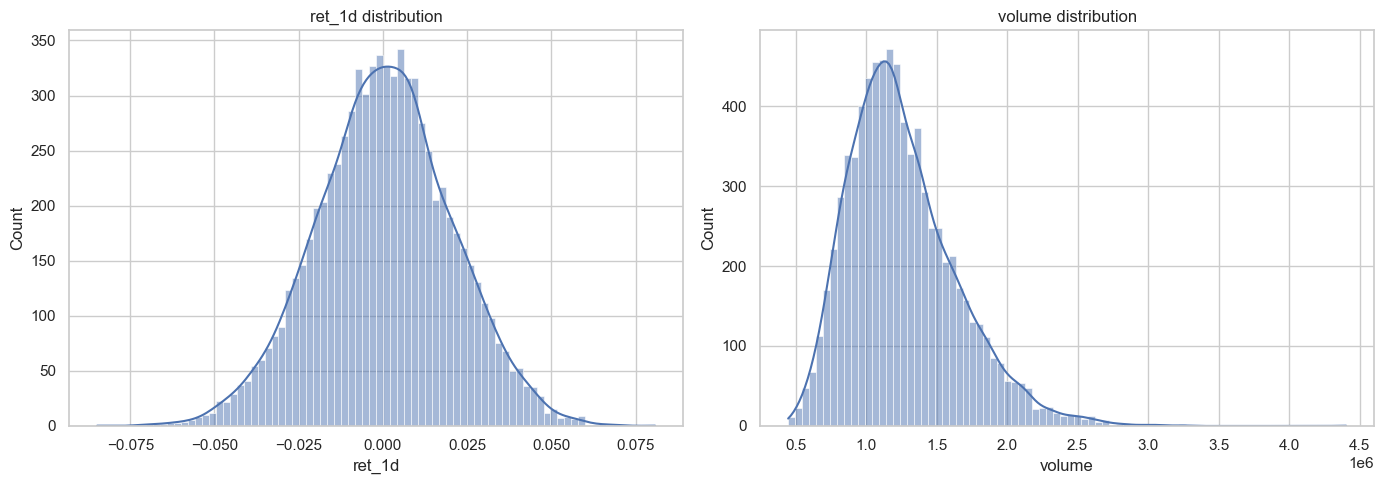

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(bars['ret_1d'], bins=80, kde=True, ax=axes[0])
axes[0].set_title('ret_1d distribution')
sns.histplot(bars['volume'], bins=80, kde=True, ax=axes[1])
axes[1].set_title('volume distribution')
plt.tight_layout()

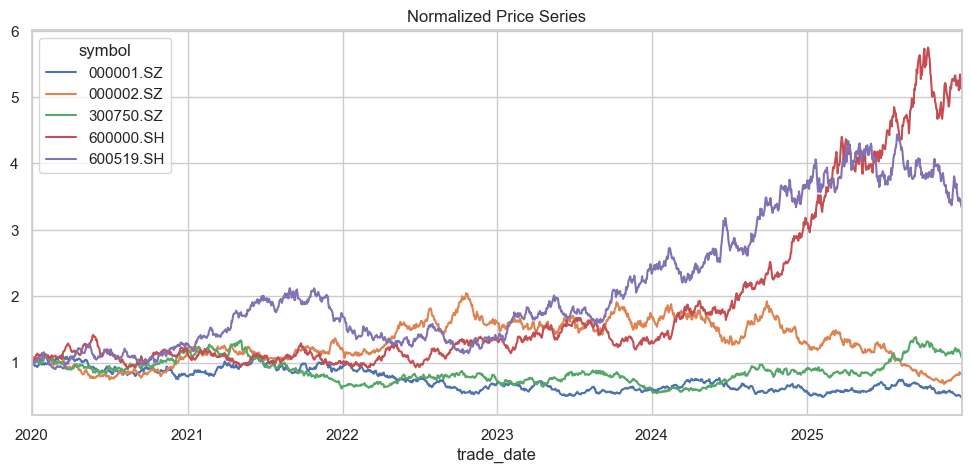

In [4]:
pivot_close = bars.pivot(index='trade_date', columns='symbol', values='close')
(pivot_close / pivot_close.iloc[0]).plot(figsize=(12, 5), title='Normalized Price Series')
plt.show()